In [15]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [16]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

Mall Customer segmentation 분석 - clustering

### 주요 변수 정의
1. **Gender**: 성별 (Male / Female) - 범주형 변수
2. **Age**: 나이 - 수치형 변수
3. **Annual Income (k$)**: 연간 수입 (단위: 천 달러) - 수치형 변수
4. **Spending Score (1-100)**: 소비 점수 (쇼핑몰에서 매긴 고객의 소비 성향/빈도 점수, 높을수록 소비 성향 강함) - 수치형 변수

- 쇼핑몰 고객의 나이, 연간 수입, 소비 점수를 기반으로 유사한 성향을 가진 고객들을 그룹(cluster)으로 묶는 프로젝트
- 머신러닝 비지도학습 중 k-means clustering을 적용

In [17]:
#df_cust = pd.read_csv('./data/project2_customers.csv', encoding = 'utf-8-sig')
data = pd.read_csv("./data/Mall_Customers.csv",encoding = 'utf-8-sig')

In [18]:
df=pd.DataFrame(data)

In [19]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [26]:
#df[['Gender','Age','Annual Income (k$)','Spending Score (1-100)']].hist(figure=(12.4),bins=12)


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

In [13]:
categorical_cols = df.select_dtypes(exclude=['number']).columns
print(categorical_cols)

numeric_cols = df.select_dtypes(include=['number']).columns
print(numeric_cols)

Index(['Gender'], dtype='object')
Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


In [20]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [21]:
for col in numeric_cols:
    print(f"--- {col} ---")
    print(df.groupby('Gender')[col].mean())
    print()

--- CustomerID ---
Gender
Female     97.562500
Male      104.238636
Name: CustomerID, dtype: float64

--- Age ---
Gender
Female    38.098214
Male      39.806818
Name: Age, dtype: float64

--- Annual Income (k$) ---
Gender
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64

--- Spending Score (1-100) ---
Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64



In [29]:
for col in numeric_cols:
    corr = df[col].corr(df['Age'])
    print(col, corr)

CustomerID -0.026762889457862923
Age 1.0
Annual Income (k$) -0.012398042736060145
Spending Score (1-100) -0.32722684603909014


In [ ]:
'''for i in categorical_cols:
    print(df.groupby('species_target')[i].value_counts())'''

In [33]:
X=df[['Age','Annual Income (k$)','Spending Score (1-100)']].copy()
feature_names=X.columns.tolist()

scaler=StandardScaler()

In [34]:
X_scaled = scaler.fit_transform(X)

In [35]:
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
X_scaled_df.agg(['mean','std']).round(4)

,Age,Annual Income (k$),Spending Score (1-100)
mean,-0.0000,-0.0000,-0.0000
std,1.0025,1.0025,1.0025


In [42]:
inertias = []

K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10 # kmeans는 서로 다른 초기 중심점으로 몇번 반복 실행할지 결정하는 값 통상10
    )
    
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

elbow_df = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias
})

elbow_df

,K,Inertia
0,2,389.386189
1,3,295.212246
2,4,205.225147
3,5,168.247580
4,6,133.868421
5,7,117.011555
6,8,103.873292
7,9,93.092891
8,10,82.385154


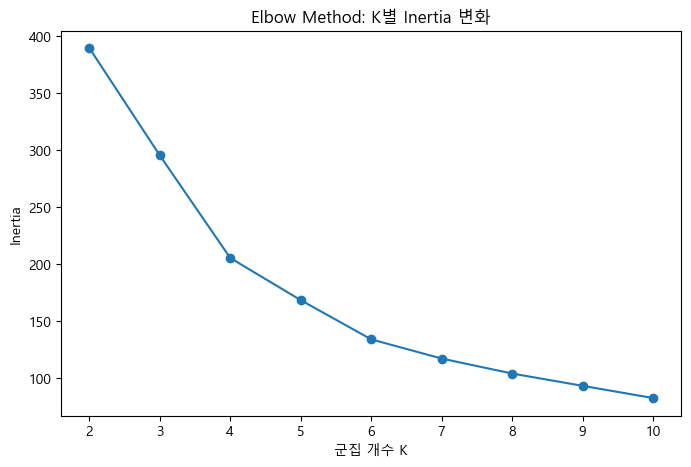

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(elbow_df["K"], elbow_df["Inertia"], marker="o")
plt.xlabel("군집 개수 K")
plt.ylabel("Inertia")
plt.title("Elbow Method: K별 Inertia 변화")
plt.xticks(list(K_range))
plt.show()

In [47]:
silhouette_results = []

for k in range(2, 11):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels_temp)
    
    silhouette_results.append({
        "K": k,
        "Silhouette_Score": sil
    })

silhouette_df = pd.DataFrame(silhouette_results)

display(silhouette_df)

,K,Silhouette_Score
0,2,0.335472
1,3,0.357793
2,4,0.403958
3,5,0.416643
4,6,0.428417
5,7,0.417232
6,8,0.408207
7,9,0.417693
8,10,0.406554


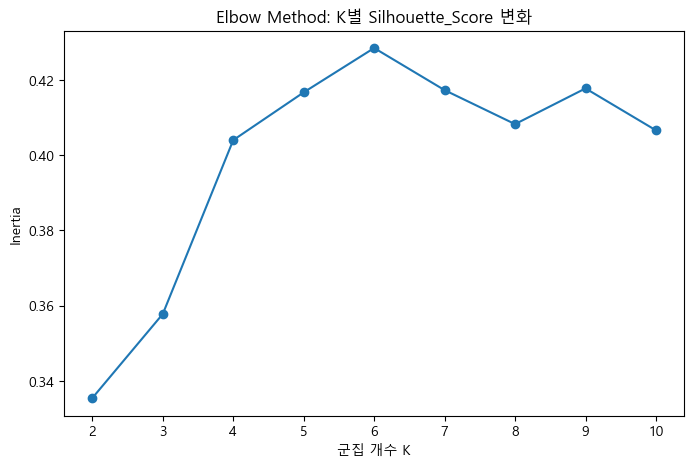

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(silhouette_df["K"], silhouette_df["Silhouette_Score"], marker="o")
plt.xlabel("군집 개수 K")
plt.ylabel("Inertia")
plt.title("Elbow Method: K별 Silhouette_Score 변화")
plt.xticks(list(K_range))
plt.show()

In [67]:
kmeans_final = KMeans(n_clusters=4, random_state=42)

df['Cluster']=kmeans_final.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
0    65
2    57
1    40
3    38
Name: count, dtype: int64


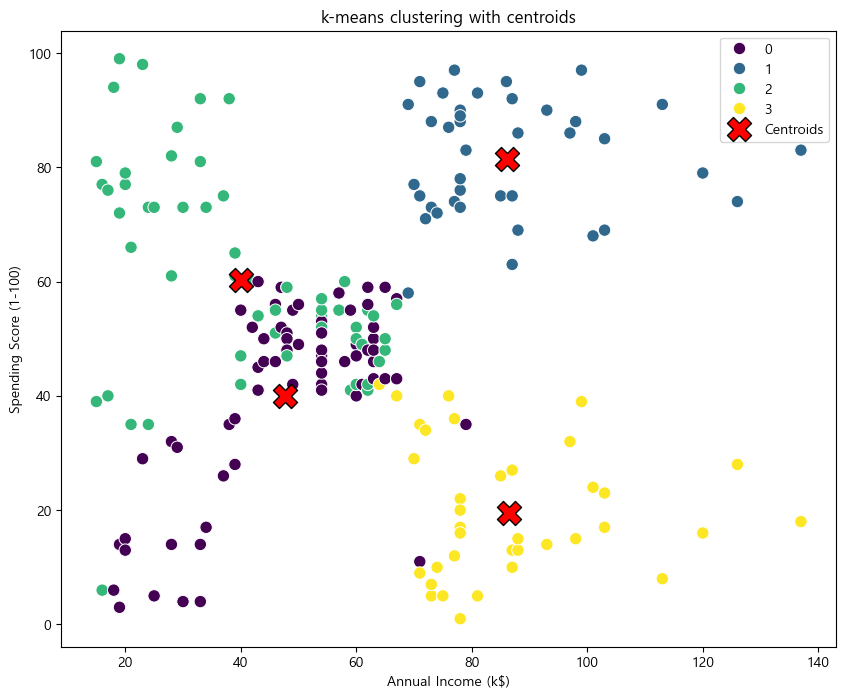

In [68]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster',palette='viridis', data=df,s=80
)

centroids_scaled= kmeans_final.cluster_centers_
centroids_original=scaler.inverse_transform(centroids_scaled)
centroids_df=pd.DataFrame(centroids_original,columns=feature_names)

plt.scatter(centroids_df['Annual Income (k$)'], centroids_df['Spending Score (1-100)'],
           marker='X',s=300,color='red',label='Centroids',edgecolor='k')

plt.title('k-means clustering with centroids')
plt.legend()
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

[연소득 : x]
- 왼쪽 : 소득 낮음 오른쪽 : 소득 높음

[소비점수 : y]
- 아래쪽 : 소비성향 낮음 위쪽 : 소비성향 높음

[전체 해석]
- 오른쪽 위 : 소득 높고 소비 높다
- 왼쪽 아래 : 소득 낮고 소비 낮음
- 왼쪽 위 : 소득 낮고 소비 높음
- 오른쪽 아래 : 소득높고 소비 낮다
- 가운데 : 평균적임


[비지도학습을 통한 데이터 인사이트 도출]
- Cluster 1 : 오른쪽 -> 고소득 고소비 => 핵심 vip
    - vip 맴버십 강화, 프리미엄 상품 추천, 한정판 상품 제안, 개인 맞추명 서비스, 우수 고객 전용 혜택
- Cluster 3 : 오른쪽 아래 -> 고소득 저소비 => 구매 이력은 있지만 아직 소비가 낮은 고객
    - 프리미엄 체험권, 개인화 추천, 첫 구매 혜택
- Cluster 2 : 왼쪽 위(중간) -> 저소득/중간소득 중간소비/고소비 => 가격에는 민감하지만 구매 의지는 높은 고객 
- Cluster 0 : 왼쪽 아래 -> 저소득/중간소득 저소비/중간소비 => 일반고객 또는 소극적 소비 고객